# Social media effectiveness — drivers of engagement (explanatory pipeline)

## 1. Problem framing

**Business problem.** Lighthouse Sanctuary uses multiple social platforms to raise awareness, recruit supporters, and drive donations. Communications leadership needs to know **which posting choices are most associated with higher audience engagement** (as measured by `engagement_rate`) so they can prioritize content formats, timing, calls to action, and paid boost decisions—without mistaking correlation for guaranteed outcomes.

**Who cares.** Marketing/comms leads, executive leadership reviewing a future **admin dashboard**, and program staff who approve story-based content.

**Why it matters.** Misreading “what works” wastes staff time on low-impact formats or over-invests in boosts on content that does not resonate. The organization needs **interpretable associations** between levers they control (topic, tone, CTA, platform, timing) and engagement—not only a black-box forecast.

**Predictive vs explanatory (textbook framing).** The textbook distinguishes **predictive** modeling (optimize out-of-sample accuracy) from **explanatory** / causal-style modeling (understand conditional relationships and assess diagnostics). **This notebook is primarily explanatory:** we estimate **multiple linear regression (MLR)** coefficients and confidence intervals (Ch. 9–10) for *leakage-safe* post attributes, holding other attributes constant in a linear approximation. We **pair** that with a **train/test split** and a **shallow regression tree** (Ch. 11–12) to show **out-of-sample error** and **nonlinear importance rankings**—those address **generalization and alternative structure**, not causal proof.

**Success criteria.** For explanation: stable signs/magnitudes of coefficients, acceptable diagnostic behavior (residuals, multicollinearity), and a clear management summary of **top associated factors**. For the predictive companion: holdout **MAE / RMSE / R²** for linear vs tree models on the same features.

**Data.** Synthetic nonprofit extract: [`lighthouse_csv_v7/social_media_posts.csv`](lighthouse_csv_v7/social_media_posts.csv). Paths below assume the notebook runs with working directory `ml-pipelines/` (recommended).


## 2. Data acquisition, preparation & exploration

We load post-level rows keyed by `post_id`. **No join** to other tables is required for this question.

### Leakage-safe feature policy (critical)

`engagement_rate` is an outcome metric that is mechanically related to **realized** reach, impressions, and interaction counts. To estimate associations with **posting decisions** (what the team chooses *before* outcomes are known), we **exclude** any column that is part of the engagement outcome or its usual denominator, plus downstream conversion metrics:

- **Excluded (leakage / post-outcome):** `likes`, `comments`, `shares`, `saves`, `click_throughs`, `video_views`, `impressions`, `reach`, `profile_visits`, `donation_referrals`, `estimated_donation_value_php`, `watch_time_seconds`, `avg_view_duration_seconds`, `subscriber_count_at_post`, `forwards`.
- **Excluded (identifiers / raw text not used here):** `post_id`, `platform_post_id`, `post_url`, `caption`, `hashtags`.

**Predictors used:** `platform`, `day_of_week`, `post_hour`, `post_type`, `media_type`, `num_hashtags`, `mentions_count`, `call_to_action_type`, `content_topic`, `sentiment_tone`, `caption_length`, `features_resident_story`, `campaign_name`, `is_boosted`, `boost_budget_php`, and **`follower_count_at_post`** (audience scale—interpreted as a **confounder**, not a content “choice”). During wrangling we still read `has_call_to_action` from the CSV only to set `call_to_action_type` to `(no CTA)` when false; we **do not** include `has_call_to_action` in the regression because it would be **perfectly collinear** with the CTA-type dummies (reference category = `(no CTA)`).

**Reference categories (for dummy coding, `drop_first=True` in pandas):** first level after **alphabetical sort** per column (e.g. `platform` reference = **Facebook**). We document this so coefficients read as contrasts vs that baseline.

**Reproducibility:** fixed `random_state=42` where randomness appears; time-based split uses `created_at` ordering.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import statsmodels.api as sm
except ImportError as e:
    raise ImportError(
        "This notebook requires statsmodels (OLS, VIF). Install with: pip install statsmodels"
    ) from e

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
DATA_DIR = ROOT / "lighthouse_csv_v7"
CSV_PATH = DATA_DIR / "social_media_posts.csv"

# Resolve ml-pipelines/ whether or not cwd is repo root
if not CSV_PATH.is_file():
    alt = ROOT / "ml-pipelines" / "lighthouse_csv_v7" / "social_media_posts.csv"
    if alt.is_file():
        CSV_PATH = alt
        DATA_DIR = alt.parent
    else:
        raise FileNotFoundError(f"Could not find social_media_posts.csv from {ROOT}")

print("Data path:", CSV_PATH.resolve())

LEAKAGE_AND_ID_COLS = [
    "post_id",
    "platform_post_id",
    "post_url",
    "caption",
    "hashtags",
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "video_views",
    "profile_visits",
    "donation_referrals",
    "estimated_donation_value_php",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "subscriber_count_at_post",
    "forwards",
]

TARGET = "engagement_rate"

FEATURE_COLS = [
    "platform",
    "day_of_week",
    "post_hour",
    "post_type",
    "media_type",
    "num_hashtags",
    "mentions_count",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "caption_length",
    "features_resident_story",
    "campaign_name",
    "is_boosted",
    "boost_budget_php",
    "follower_count_at_post",
]

raw = pd.read_csv(CSV_PATH)
print("Rows:", len(raw), "Cols:", raw.shape[1])


Data path: /Users/rental/Intex-II/ml-pipelines/lighthouse_csv_v7/social_media_posts.csv
Rows: 812 Cols: 39


In [2]:
from db_config import engine, USE_DB, text

TRUTHY = {'1', 'true', 'yes', 't', 'y'}
FALSY  = {'0', 'false', 'no', 'f', 'n'}
BOOL_STRINGS = TRUTHY | FALSY

def load_table(table_name: str, csv_filename: str, parse_dates=None, **kwargs):
    """Load a table from Azure SQL when USE_DB=True, otherwise fall back to CSV."""
    import pandas as pd, os
    if USE_DB:
        df = pd.read_sql_table(table_name, engine)
        date_set = set(parse_dates or [])
        for col in date_set:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
        for col in df.select_dtypes(include='object').columns:
            if col in date_set:
                continue
            non_null = df[col].notna().sum()
            if non_null == 0:
                continue
            # Try numeric first (handles '0'/'1', DECIMAL values like '717.18')
            converted = pd.to_numeric(df[col], errors='coerce')
            if converted.notna().sum() == non_null:
                df[col] = converted
                continue
            # Try boolean-string coercion ('Yes'/'No', 'True'/'False', '0'/'1')
            unique_lower = {str(v).lower() for v in df[col].dropna().unique()}
            if unique_lower <= BOOL_STRINGS:
                df[col] = df[col].map(
                    lambda x: 1 if str(x).lower() in TRUTHY else (0 if pd.notna(x) else pd.NA)
                ).astype('Int64')
        return df
    else:
        csv_path = os.path.join('lighthouse_csv_v7', csv_filename)
        return pd.read_csv(csv_path, parse_dates=parse_dates or [], **kwargs)


✓ DB connection established (source: appsettings.Development.json )


In [3]:
# Override raw with DB data when available
if USE_DB:
    import pandas as pd
    raw = pd.read_sql('SELECT * FROM social_media_posts', engine)
    print(f'✓ Loaded {len(raw)} posts from Azure SQL')
else:
    print(f'Using local CSV ({len(raw)} rows)')

✓ Loaded 812 posts from Azure SQL


In [4]:
# Parse timestamps for time-based split later
raw["created_at"] = pd.to_datetime(raw["created_at"], errors="coerce")


def wrangle_social_posts(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["has_call_to_action", "features_resident_story", "is_boosted"]:
        out[c] = out[c].astype(bool)
    out["call_to_action_type"] = out["call_to_action_type"].fillna("").astype(str).str.strip()
    out.loc[~out["has_call_to_action"], "call_to_action_type"] = "(no CTA)"
    out.loc[out["call_to_action_type"] == "", "call_to_action_type"] = "(no CTA)"
    out["boost_budget_php"] = pd.to_numeric(out["boost_budget_php"], errors="coerce").fillna(0.0)
    out.loc[~out["is_boosted"], "boost_budget_php"] = 0.0
    out["campaign_name"] = out["campaign_name"].fillna("(no campaign)").astype(str)
    vc = out["campaign_name"].value_counts(normalize=True)
    rare = vc[vc < 0.05].index.tolist()
    if rare:
        out["campaign_name"] = out["campaign_name"].replace({r: "Other_campaign" for r in rare})
    return out


df = wrangle_social_posts(raw)
y = df[TARGET].astype(float)

feature_df = df[FEATURE_COLS]
print(feature_df.dtypes)


platform                    object
day_of_week                 object
post_hour                    int64
post_type                   object
media_type                  object
num_hashtags                 int64
mentions_count               int64
call_to_action_type         object
content_topic               object
sentiment_tone              object
caption_length               int64
features_resident_story       bool
campaign_name               object
is_boosted                    bool
boost_budget_php           float64
follower_count_at_post       int64
dtype: object


,count,mean,std,min,25%,50%,75%,max,missing
post_hour,812.0,12.690887,6.296557,0.0,8.0,13.0,18.0,23.00,0
num_hashtags,812.0,2.046798,1.414310,0.0,1.0,2.0,3.0,5.00,0
mentions_count,812.0,0.612069,0.853514,0.0,0.0,0.0,1.0,3.00,0
caption_length,812.0,137.318966,28.559851,67.0,121.0,137.0,152.0,220.00,0
boost_budget_php,812.0,380.084039,1037.743010,0.0,0.0,0.0,0.0,4966.98,0
follower_count_at_post,812.0,1502.307882,688.176221,360.0,916.0,1543.0,1833.0,2489.00,0



Target engagement_rate describe:


count    812.000000
mean       0.098980
std        0.055541
min        0.013400
25%        0.054600
50%        0.089300
75%        0.136825
max        0.250000
Name: engagement_rate, dtype: float64

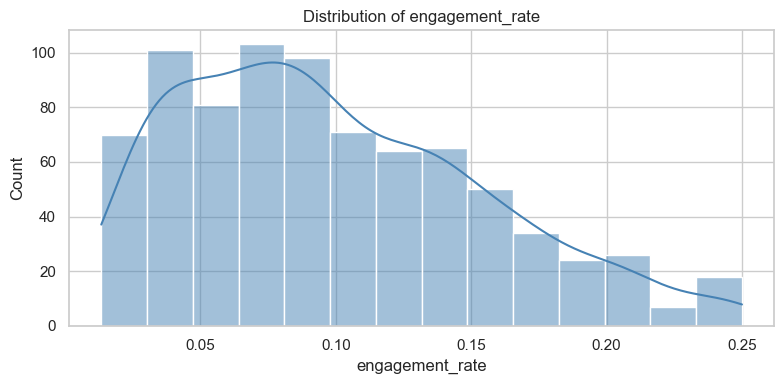

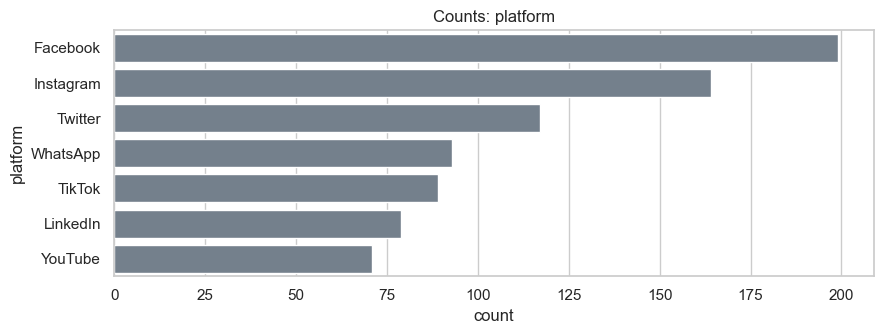

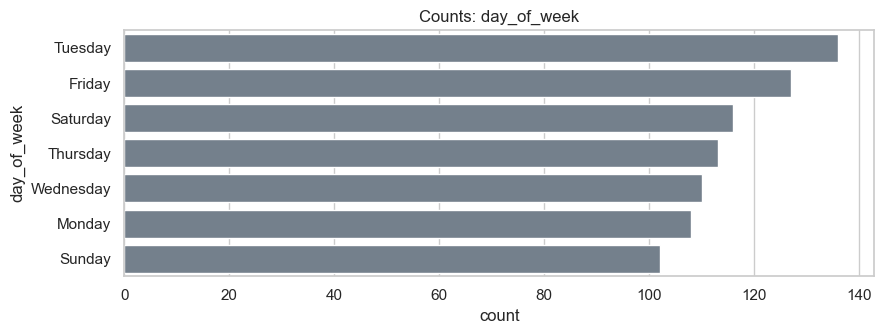

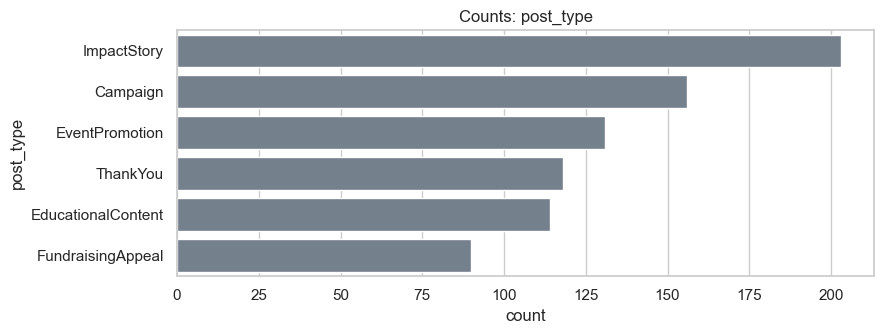

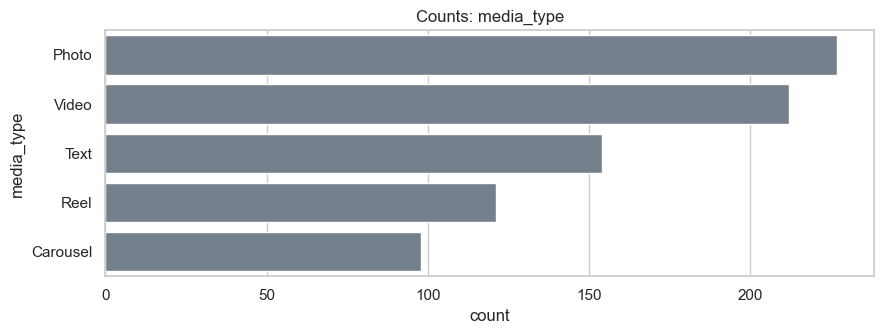

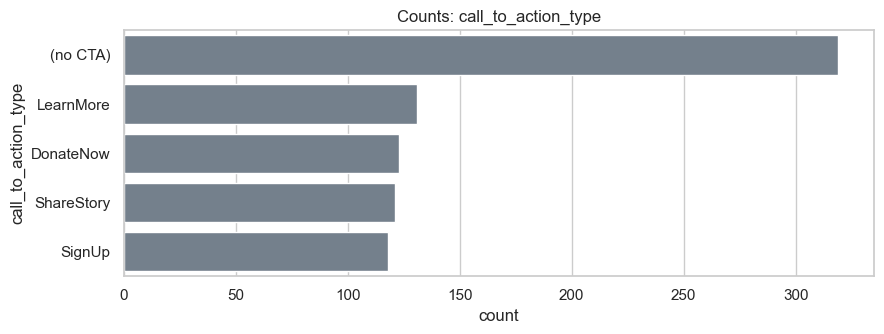

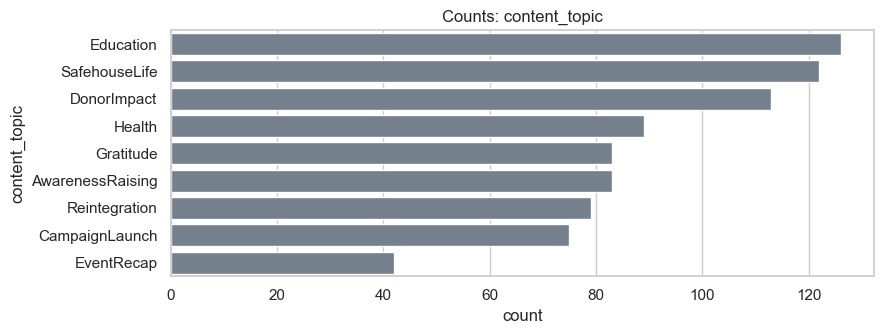

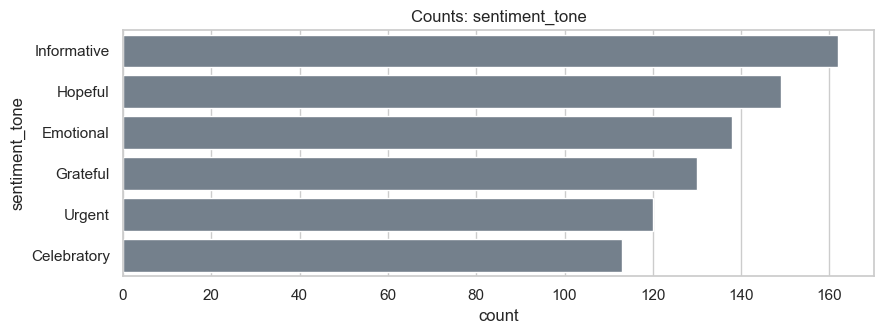

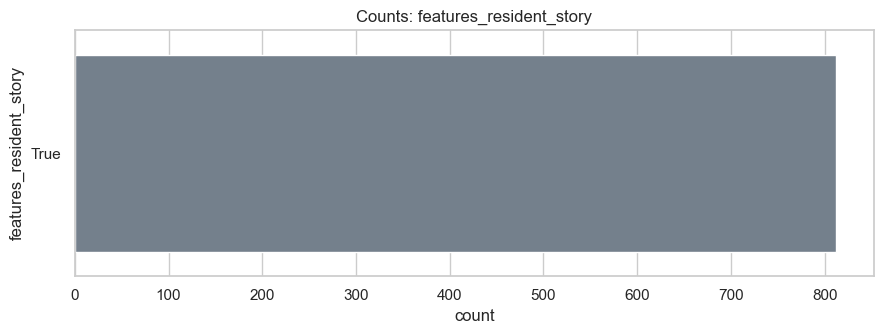

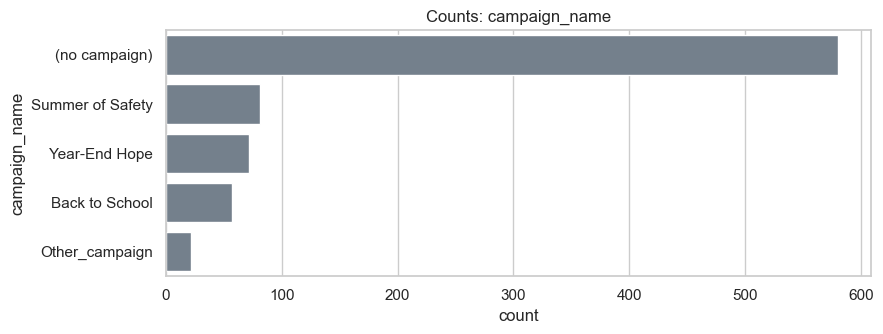

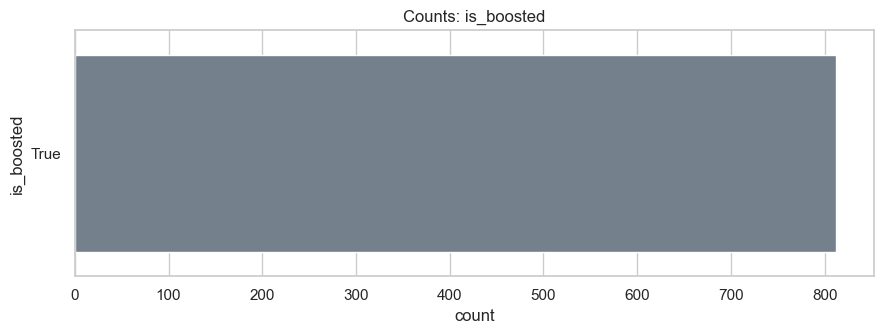

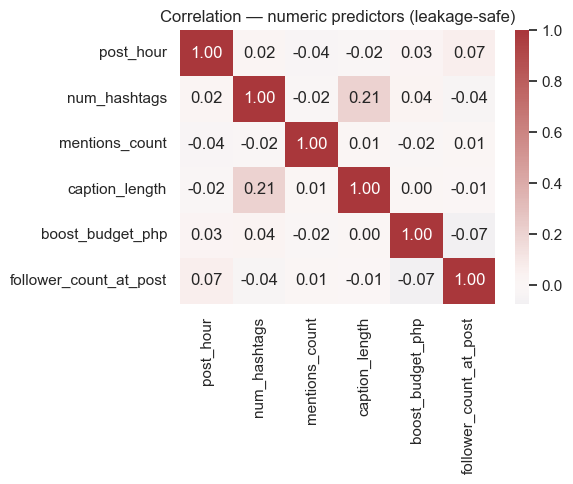

In [5]:
# Univariate-style summary for key numerics
num_summary = feature_df.select_dtypes(include=[np.number]).describe().T
num_summary["missing"] = feature_df.select_dtypes(include=[np.number]).isna().sum()
display(num_summary)

print("\nTarget engagement_rate describe:")
display(y.describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(y, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of engagement_rate")
plt.tight_layout()
plt.show()

# Categorical frequencies
cat_cols = [
    c
    for c in feature_df.columns
    if feature_df[c].dtype == object or str(feature_df[c].dtype) == "bool"
]
for c in cat_cols:
    plt.figure(figsize=(9, 3.5))
    order = feature_df[c].value_counts().index[:12]
    sns.countplot(data=feature_df, y=c, order=order, color="slategray")
    plt.title(f"Counts: {c}")
    plt.tight_layout()
    plt.show()

num_only = feature_df.select_dtypes(include=[np.number])
plt.figure(figsize=(6, 5))
sns.heatmap(num_only.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation — numeric predictors (leakage-safe)")
plt.tight_layout()
plt.show()


## 3. Modeling & feature selection

**Primary explanatory model:** **OLS** via `statsmodels` on the full sample, with **HC3 robust standard errors** (Ch. 10). Categoricals enter as **dummy variables** (`pd.get_dummies(..., drop_first=True)`); **numeric predictors are standardized (z-scores)** in the OLS design matrix so coefficients are comparable in magnitude (Ch. 9).

**Feature selection (Ch. 16, causal lens):** we start from **theory-backed levers** (platform, format, timing, CTA, topic, tone, boost). Rare `campaign_name` levels are collapsed. We omit `has_call_to_action` from the design matrix because it is **linearly determined** by `call_to_action_type` (reference = `(no CTA)`). We then compute **variance inflation factors (VIF)** and discuss multicollinearity—especially **`is_boosted` vs `boost_budget_php`**.

**Regression diagnostics (Ch. 10)** and a **Box–Cox–adjusted OLS** follow the initial fit.

**Comparison model:** **shallow `DecisionTreeRegressor`** (Ch. 12) with one-hot encoded features fit inside a sklearn `Pipeline` to show **nonlinear splits** and **impurity-based feature importance** as a complement—not a causal estimator.


In [6]:
# Design matrix for OLS: standardize numerics, dummies for categoricals + bools

NUM_COLS = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "boost_budget_php",
    "follower_count_at_post",
]
CAT_COLS = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "campaign_name",
]
BOOL_COLS = ["features_resident_story", "is_boosted"]


def build_ols_design(df_in: pd.DataFrame):
    X = df_in.copy()
    z_cols = []
    for c in NUM_COLS:
        mu = X[c].astype(float).mean()
        sd = X[c].astype(float).std(ddof=0)
        if sd and sd > 0:
            X[f"z_{c}"] = (X[c].astype(float) - mu) / sd
        else:
            X[f"z_{c}"] = 0.0
        z_cols.append(f"z_{c}")
    X_bool = X[BOOL_COLS].astype(int)
    X_cat = pd.get_dummies(X[CAT_COLS].astype(str), drop_first=True, dtype=float)
    Xd = pd.concat([X[z_cols], X_bool, X_cat], axis=1)
    return Xd, z_cols


Xd, Z_COLS = build_ols_design(feature_df)
Xd = sm.add_constant(Xd, has_constant="add")
ols_model = sm.OLS(y.values, Xd.astype(float))
ols_res = ols_model.fit(cov_type="HC3")
print(ols_res.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     101.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.12e-298
Time:                        12:31:01   Log-Likelihood:                 1435.5
No. Observations:                 812   AIC:                            -2773.
Df Residuals:                     763   BIC:                            -2543.
Df Model:                          48                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF excludes the intercept (Ch. 10); including const inflates diagnostics misleadingly
Xd_vif = Xd.drop(columns=["const"], errors="ignore")
vif_df = pd.DataFrame(
    {
        "feature": Xd_vif.columns,
        "VIF": [
            variance_inflation_factor(Xd_vif.values.astype(float), i)
            for i in range(Xd_vif.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)
display(vif_df.head(20))

print("\nRule of thumb: VIF > 5–10 suggests multicollinearity worth discussing (Ch. 10).")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
5,z_follower_count_at_post,39.125638
9,platform_LinkedIn,29.473870
13,platform_YouTube,24.082016
10,platform_TikTok,21.835628
11,platform_Twitter,16.951061
12,platform_WhatsApp,8.577453
8,platform_Instagram,7.099645
28,media_type_Video,2.832450
26,media_type_Reel,2.636426
25,media_type_Photo,2.573872



Rule of thumb: VIF > 5–10 suggests multicollinearity worth discussing (Ch. 10).


### Regression diagnostics (Ch. 10)

We assess **normality of residuals**, **homoscedasticity** (constant error variance), and **linearity** of the mean structure—assumptions that matter for **inference on OLS coefficients** (Ch. 10), not for pure prediction. We report **Jarque–Bera** and **Omnibus** normality tests, **Breusch–Pagan** for heteroscedasticity, a **residual histogram**, **Q–Q plot**, and **residuals vs. fitted**.

Jarque–Bera normality test
  statistic = 14.3146, p-value = 0.0007792
  skewness = 0.2954, kurtosis = 2.7278

Omnibus normality test (skew/kurtosis)
  statistic = 14.5291, p-value = 0.0006999

Breusch–Pagan test for heteroscedasticity
  LM statistic = 197.6614, LM p-value = 1.915e-19
  F statistic = 5.1144, F p-value = 1.064e-23


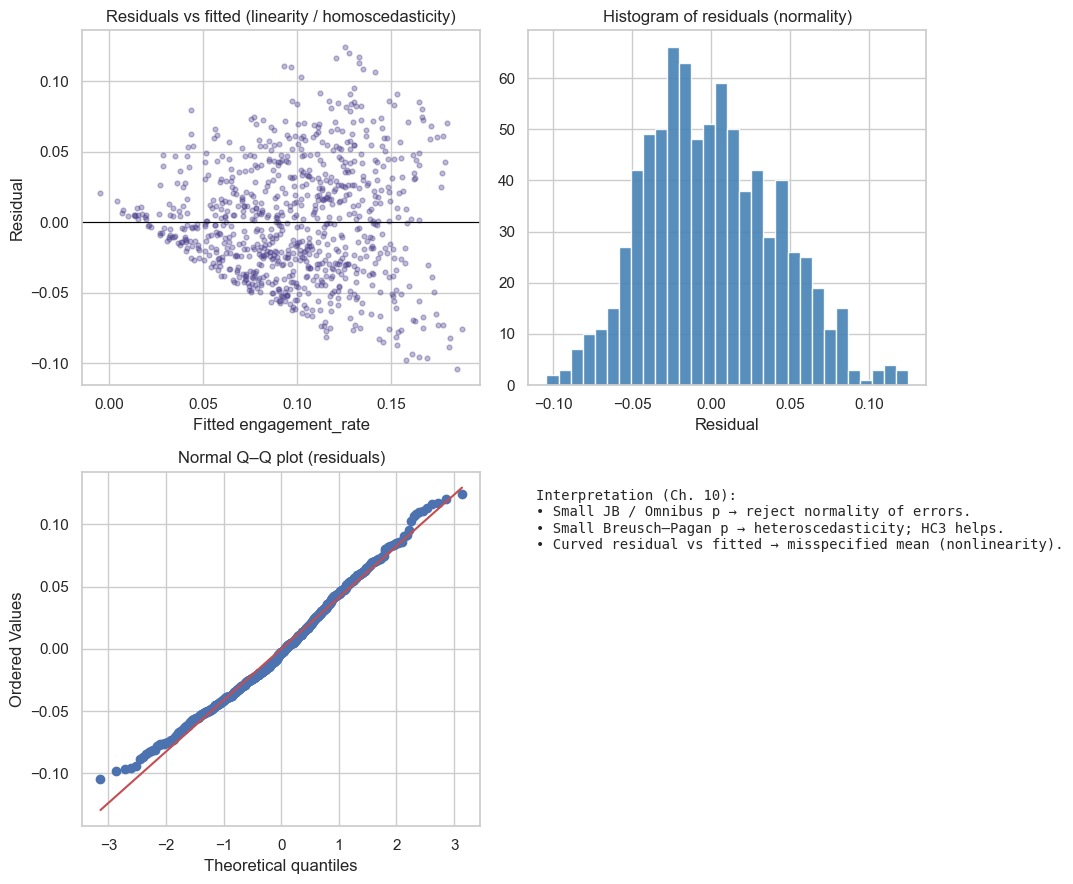

In [8]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, omni_normtest

fitted = ols_res.fittedvalues
resid = ols_res.resid

jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print("Jarque–Bera normality test")
print(f"  statistic = {jb_stat:.4f}, p-value = {jb_p:.4g}")
print(f"  skewness = {skew:.4f}, kurtosis = {kurt:.4f}")

omni_stat, omni_p = omni_normtest(resid)
print("\nOmnibus normality test (skew/kurtosis)")
print(f"  statistic = {omni_stat:.4f}, p-value = {omni_p:.4g}")

bp_lm, bp_lmp, bp_f, bp_fp = het_breuschpagan(resid, Xd.astype(float))
print("\nBreusch–Pagan test for heteroscedasticity")
print(f"  LM statistic = {bp_lm:.4f}, LM p-value = {bp_lmp:.4g}")
print(f"  F statistic = {bp_f:.4f}, F p-value = {bp_fp:.4g}")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes[0, 0].scatter(fitted, resid, alpha=0.35, s=12, color="darkslateblue")
axes[0, 0].axhline(0, color="black", lw=0.8)
axes[0, 0].set_xlabel("Fitted engagement_rate")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].set_title("Residuals vs fitted (linearity / homoscedasticity)")

axes[0, 1].hist(resid, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[0, 1].set_title("Histogram of residuals (normality)")
axes[0, 1].set_xlabel("Residual")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Normal Q–Q plot (residuals)")

axes[1, 1].axis("off")
axes[1, 1].text(
    0.02,
    0.95,
    "Interpretation (Ch. 10):\n"
    "• Small JB / Omnibus p → reject normality of errors.\n"
    "• Small Breusch–Pagan p → heteroscedasticity; HC3 helps.\n"
    "• Curved residual vs fitted → misspecified mean (nonlinearity).",
    va="top",
    fontsize=10,
    family="monospace",
    transform=axes[1, 1].transAxes,
)
plt.tight_layout()
plt.show()


### Diagnostic-adjusted OLS (Ch. 10)

`engagement_rate` is **right-skewed**. A **Box–Cox** transform (strictly positive `y`; we only shift if needed) can stabilize variance and improve residual normality, supporting more credible **inference** in the linear model on the transformed scale. We refit **OLS** with **HC3**. Coefficients describe associations on the **Box–Cox scale**, not literal rate points; we compare **Jarque–Bera** and **Breusch–Pagan** *p*-values before vs after. **Goal: inference validity**, not maximizing test RMSE (Ch. 10 vs Ch. 11).

Box–Cox lambda (MLE): 0.3684
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     1590.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:31:03   Log-Likelihood:                 260.20
No. Observations:                 812   AIC:                            -422.4
Df Residuals:                     763   BIC:                            -192.1
Df Model:                          48                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

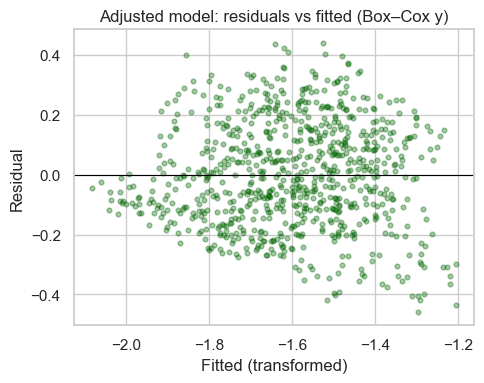

In [9]:
from scipy.stats import boxcox

y_pos = y.astype(float).values
if y_pos.min() <= 0:
    y_pos = y_pos - y_pos.min() + 1e-6

y_bc, boxcox_lambda = boxcox(y_pos)
print(f"Box–Cox lambda (MLE): {boxcox_lambda:.4f}")

ols_adj = sm.OLS(y_bc, Xd.astype(float)).fit(cov_type="HC3")
print(ols_adj.summary())

resid_adj = ols_adj.resid
jb_a, jb_pa, _, _ = jarque_bera(resid_adj)
_, bp_lmp_a = het_breuschpagan(resid_adj, Xd.astype(float))[:2]
print("\n--- After Box–Cox on y ---")
print(f"Jarque–Bera p-value: {jb_pa:.4g} (was {jb_p:.4g} on original scale)")
print(f"Breusch–Pagan LM p-value: {bp_lmp_a:.4g} (was {bp_lmp:.4g})")
print(
    "Note: BP p often moves toward non-rejection when variance stabilizes; "
    "JB may still reject if tails remain non-Gaussian. HC3 remains appropriate."
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(ols_adj.fittedvalues, resid_adj, alpha=0.35, s=12, color="darkgreen")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Adjusted model: residuals vs fitted (Box–Cox y)")
ax.set_xlabel("Fitted (transformed)")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()


In [10]:
# Robustness: OLS without follower_count (audience confounder sensitivity)
feature_df_nof = feature_df.drop(columns=["follower_count_at_post"])
NUM_COLS_NOF = [c for c in NUM_COLS if c != "follower_count_at_post"]


def build_ols_design_custom(df_in: pd.DataFrame, num_cols: list) -> pd.DataFrame:
    X = df_in.copy()
    z_cols = []
    for c in num_cols:
        mu = X[c].astype(float).mean()
        sd = X[c].astype(float).std(ddof=0)
        if sd and sd > 0:
            X[f"z_{c}"] = (X[c].astype(float) - mu) / sd
        else:
            X[f"z_{c}"] = 0.0
        z_cols.append(f"z_{c}")
    X_bool = X[BOOL_COLS].astype(int)
    X_cat = pd.get_dummies(X[CAT_COLS].astype(str), drop_first=True, dtype=float)
    return pd.concat([X[z_cols], X_bool, X_cat], axis=1)


Xd2 = sm.add_constant(build_ols_design_custom(feature_df_nof, NUM_COLS_NOF), has_constant="add")
ols_res_nof = sm.OLS(y.values, Xd2.astype(float)).fit(cov_type="HC3")
print("R-squared with follower_count:", round(ols_res.rsquared, 4))
print("R-squared without follower_count:", round(ols_res_nof.rsquared, 4))
print("\nTop |t| without follower_count (15 largest):")
print(ols_res_nof.tvalues.abs().sort_values(ascending=False).head(15))


R-squared with follower_count: 0.4463
R-squared without follower_count: 0.4461

Top |t| without follower_count (15 largest):
z_post_hour                       15.403852
sentiment_tone_Informative        11.244500
is_boosted                        10.011466
features_resident_story           10.011466
const                             10.011466
sentiment_tone_Grateful            7.204057
call_to_action_type_ShareStory     4.869115
sentiment_tone_Hopeful             4.772014
call_to_action_type_SignUp         3.717646
call_to_action_type_LearnMore      3.475139
platform_Instagram                 3.091172
call_to_action_type_DonateNow      2.747950
sentiment_tone_Urgent              2.590627
platform_Twitter                   1.809174
platform_YouTube                   1.798496
dtype: float64


## 4. Evaluation & interpretation

**Explanatory (OLS).** We emphasize **coefficients**, **HC3 intervals**, and **diagnostics** above. The **Box–Cox–adjusted** specification improves **inference-oriented** residual behavior (Ch. 10); it is not chosen to minimize test RMSE.

**Predictive workflow (Ch. 11)** is **separate** from explanatory inference: **time-ordered 60% / 20% / 20%** train / validation / test on `created_at`. **Greedy backward feature removal** starts from the full encoded design, then **repeatedly drops the single feature whose removal yields the lowest validation RMSE** among all one-feature removals, until one feature remains. We plot **validation MAE and RMSE** over that full trace and **select the model size at the global minimum validation RMSE** for **final test** scoring.

**Decision trees (Ch. 12).** We **sweep `max_depth`**, plot **train vs validation RMSE** (bias–variance), select the depth with **best validation RMSE**, then **`plot_tree`** (display depth capped for readability) and **feature importances**.

**Business read.** Validation guides model *complexity*; **test** is a single forward-time check. Patterns remain **associational** unless confirmed by experiments.


Train / Val / Test: 487 162 163
Test date range: 2025-07-18 17:56:00 → 2026-02-26 21:56:00


Greedy trace: 58 steps; global best val RMSE at n_features=20


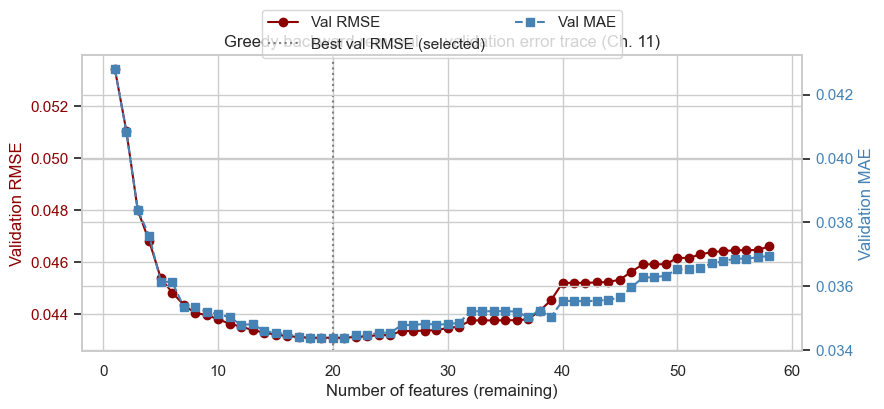

Test LinearRegression (greedy-selected features): MAE=0.03482  RMSE=0.04229  R2=0.3877


In [11]:
# Ch. 11: Time-ordered 60% / 20% / 20% train / validation / test
order = np.argsort(df["created_at"].values)
idx_rank = np.empty_like(order)
idx_rank[order] = np.arange(len(order))
n = len(df)
cut60 = int(np.floor(0.6 * n))
cut80 = int(np.floor(0.8 * n))

train_mask = idx_rank < cut60
val_mask = (idx_rank >= cut60) & (idx_rank < cut80)
test_mask = idx_rank >= cut80

X_train = feature_df.loc[train_mask]
X_val = feature_df.loc[val_mask]
X_test = feature_df.loc[test_mask]
y_train = y.loc[train_mask]
y_val = y.loc[val_mask]
y_test = y.loc[test_mask]

print("Train / Val / Test:", len(X_train), len(X_val), len(X_test))
print(
    "Test date range:",
    df.loc[test_mask, "created_at"].min(),
    "→",
    df.loc[test_mask, "created_at"].max(),
)

numeric_features = NUM_COLS
categorical_features = CAT_COLS + BOOL_COLS

try:
    _one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", _one_hot, categorical_features),
    ]
)

X_tr = preprocess.fit_transform(X_train)
X_va = preprocess.transform(X_val)
X_te = preprocess.transform(X_test)


def rmse_(a, b):
    return mean_squared_error(a, b) ** 0.5


# --- Greedy backward feature removal (minimize validation RMSE each step) ---
active = list(range(X_tr.shape[1]))
greedy_history = []


def lin_fit_predict(act):
    reg = LinearRegression()
    reg.fit(X_tr[:, act], y_train)
    pred_va = reg.predict(X_va[:, act])
    pred_tr = reg.predict(X_tr[:, act])
    return reg, pred_tr, pred_va


while len(active) >= 1:
    reg, pred_tr, pred_va = lin_fit_predict(active)
    mae_v = mean_absolute_error(y_val, pred_va)
    rmse_v = rmse_(y_val, pred_va)
    mae_tr = mean_absolute_error(y_train, pred_tr)
    rmse_tr = rmse_(y_train, pred_tr)
    greedy_history.append(
        {
            "n_features": len(active),
            "mae_val": mae_v,
            "rmse_val": rmse_v,
            "mae_train": mae_tr,
            "rmse_train": rmse_tr,
            "active": tuple(active),
        }
    )
    if len(active) <= 1:
        break
    best_rmse = np.inf
    best_drop = None
    for j in active:
        sub = [k for k in active if k != j]
        _, _, pv = lin_fit_predict(sub)
        r = rmse_(y_val, pv)
        if r < best_rmse:
            best_rmse = r
            best_drop = j
    active.remove(best_drop)

gh = pd.DataFrame(greedy_history)
best_row = gh.loc[gh["rmse_val"].idxmin()]
optimal_active = list(best_row["active"])
print(
    f"Greedy trace: {len(greedy_history)} steps; global best val RMSE at n_features={int(best_row['n_features'])}"
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(gh["n_features"], gh["rmse_val"], "o-", color="darkred", label="Val RMSE")
ax1.axvline(
    int(best_row["n_features"]),
    color="gray",
    ls=":",
    lw=1.5,
    label="Best val RMSE (selected)",
)
ax1.set_xlabel("Number of features (remaining)")
ax1.set_ylabel("Validation RMSE", color="darkred")
ax1.tick_params(axis="y", labelcolor="darkred")
ax2 = ax1.twinx()
ax2.plot(gh["n_features"], gh["mae_val"], "s--", color="steelblue", label="Val MAE")
ax2.set_ylabel("Validation MAE", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("Greedy backward removal — validation error trace (Ch. 11)")
fig.tight_layout()
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.show()

lin_final = LinearRegression()
lin_final.fit(X_tr[:, optimal_active], y_train)
pred_lin = lin_final.predict(X_te[:, optimal_active])


def report_split(name, y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = rmse_(y_true, y_hat)
    r2 = r2_score(y_true, y_hat)
    print(f"{name}: MAE={mae:.5f}  RMSE={rmse:.5f}  R2={r2:.4f}")


report_split("Test LinearRegression (greedy-selected features)", y_test, pred_lin)


Validation RMSE by max_depth: {2: 0.04457907554011441, 4: 0.04356865083323215, 6: 0.04040865514583421, 8: 0.04002310989176745, 10: 0.040338800793104625}
Selected max_depth (min validation RMSE): 8


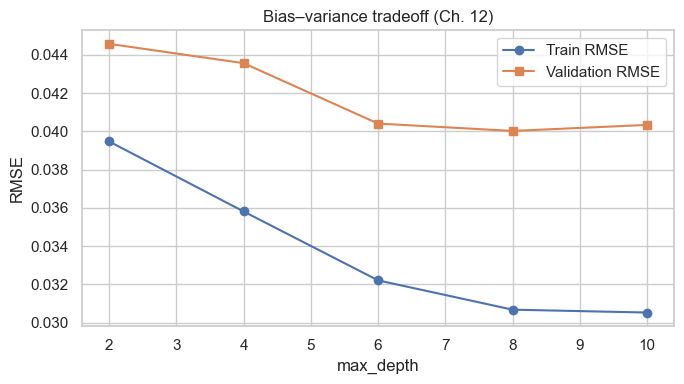

Test DecisionTree (max_depth=8): MAE=0.02933  RMSE=0.03643  R2=0.5457


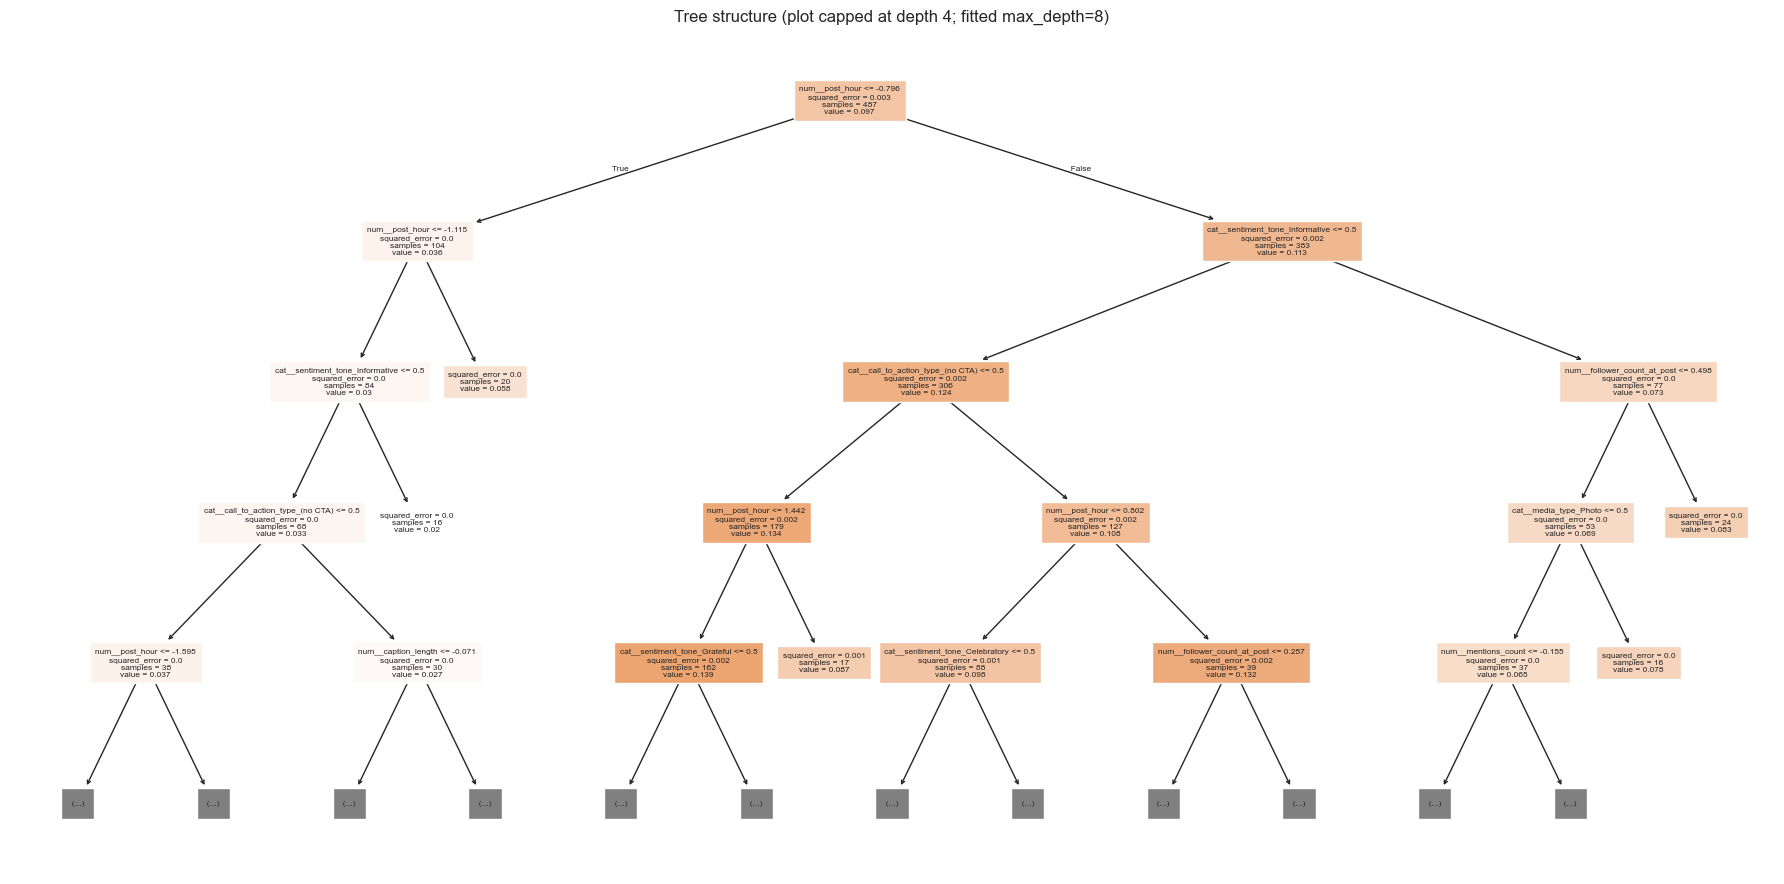

,feature,importance
0,num__post_hour,0.631064
49,cat__sentiment_tone_Informative,0.163781
31,cat__call_to_action_type_(no CTA),0.055200
47,cat__sentiment_tone_Grateful,0.040335
48,cat__sentiment_tone_Hopeful,0.039000
45,cat__sentiment_tone_Celebratory,0.018512
46,cat__sentiment_tone_Emotional,0.017011
34,cat__call_to_action_type_ShareStory,0.014408
5,num__follower_count_at_post,0.013722
2,num__mentions_count,0.004952


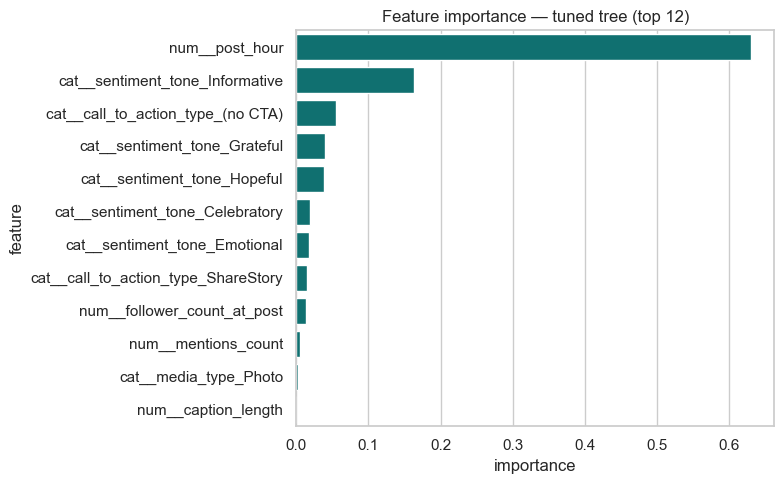

In [12]:
from sklearn.tree import plot_tree

# Ch. 12: max_depth sweep (bias–variance) + plot_tree
depths = [2, 4, 6, 8, 10]
train_rmse_d, val_rmse_d = [], []

for d in depths:
    dt = DecisionTreeRegressor(
        max_depth=d, min_samples_leaf=15, random_state=RANDOM_STATE
    )
    dt.fit(X_tr, y_train)
    train_rmse_d.append(rmse_(y_train, dt.predict(X_tr)))
    val_rmse_d.append(rmse_(y_val, dt.predict(X_va)))

best_depth = int(depths[int(np.argmin(val_rmse_d))])
print("Validation RMSE by max_depth:", dict(zip(depths, val_rmse_d)))
print("Selected max_depth (min validation RMSE):", best_depth)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_rmse_d, "o-", label="Train RMSE")
ax.plot(depths, val_rmse_d, "s-", label="Validation RMSE")
ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE")
ax.set_title("Bias–variance tradeoff (Ch. 12)")
ax.legend()
plt.tight_layout()
plt.show()

try:
    _one_hot_t = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _one_hot_t = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", _one_hot_t, categorical_features),
    ]
)

tree_pipe = Pipeline(
    [
        ("prep", preprocess_tree),
        (
            "reg",
            DecisionTreeRegressor(
                max_depth=best_depth, min_samples_leaf=15, random_state=RANDOM_STATE
            ),
        ),
    ]
)
tree_pipe.fit(X_train, y_train)
pred_tree = tree_pipe.predict(X_test)
report_split(f"Test DecisionTree (max_depth={best_depth})", y_test, pred_tree)

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(
    tree_pipe.named_steps["reg"],
    max_depth=4,
    feature_names=tree_pipe.named_steps["prep"].get_feature_names_out(),
    fontsize=6,
    filled=True,
    ax=ax,
)
ax.set_title(
    f"Tree structure (plot capped at depth 4; fitted max_depth={best_depth})"
)
plt.tight_layout()
plt.show()

prep_fitted = tree_pipe.named_steps["prep"]
feat_names = prep_fitted.get_feature_names_out()
imps = tree_pipe.named_steps["reg"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": imps}).sort_values(
    "importance", ascending=False
)
display(imp_df.head(18))

plt.figure(figsize=(8, 5))
top = imp_df.head(12)
sns.barplot(data=top, y="feature", x="importance", color="teal")
plt.title("Feature importance — tuned tree (top 12)")
plt.tight_layout()
plt.show()


## 5. Causal and relationship analysis

**What the MLR coefficients mean (Ch. 9).** Each estimated coefficient is a **conditional association**: the expected change in `engagement_rate` associated with a one-standard-deviation increase in a z-scored numeric predictor, or a switch relative to the **reference category** for a dummy, **holding the linear model’s other terms fixed**. That is **not** the same as manipulating that factor in the real world (Ch. 10).

**What the tree importance means (Ch. 12).** Impurity-based importance reflects **how often splits use a feature** and how much they reduce error within the training partition of the tree model. It can highlight **interactions** and **thresholds** the linear model misses, but it is still **not a causal effect**.

**Features that often rank highly and why they might appear**

- **`follower_count_at_post`:** Larger accounts may see systematically different rates (algorithm, audience composition). This is classic **confounding**: the coefficient mixes “audience scale” with “content quality.” Our **robustness model without follower count** shows how sensitive coefficient rankings are to this variable.
- **`is_boosted` / `boost_budget_php`:** Paid reach changes who sees a post; teams may also **choose to boost stronger creative**, so boost variables carry **selection bias** (better posts get budget).
- **Platform / media type:** Different platforms compute and report engagement differently in real life; here, synthetic data still makes **cross-platform comparisons** a **description of this dataset**, not universal laws.
- **Topic / tone / CTA:** CTA coefficients contrast specific CTAs against the **`(no CTA)`** baseline (we avoid also including `has_call_to_action`, which would be redundant). These are among the most **actionable** levers in the table, but they still correlate with campaigns, formats, and platform norms—**observational**, not proven incremental lift from adding a CTA.

**Correlation vs causation.** We **cannot** defend a claim like “urgent tone *causes* higher engagement” without **randomized posting** or a credible **quasi-experimental** design. **Honest limitations:** unobserved confounders (staff skill, external news cycles, algorithm changes over time) are not in `social_media_posts.csv`.

**False positives / false negatives (management lens).** A **false positive** association might push the org to copy a format that will not replicate. A **false negative** might hide a useful tactic the linear model cannot separate because of multicollinearity or nonlinearity—hence the tree companion and the diagnostic plots.


**Ch. 10 vs Ch. 11 in this notebook.** **Diagnostic tests and Box–Cox** target **validity of inference** on OLS (residual behavior, heteroscedasticity). **Train/validation/test splits**, **greedy backward removal**, and **tree depth tuning** target **predictive generalization**—they must not be read as strengthening causal claims.


## 6. Deployment notes (future integration)

**Not wired to the web app in this sprint.** The intended product is an **admin dashboard panel** listing **ranked engagement drivers** with short plain-language descriptions.

**Suggested integration (later)**

1. **Batch insights job** (monthly): read new rows from `social_media_posts` (or the operational warehouse), refit or load a versioned model, write a JSON artifact or DB table consumed by the .NET API.
2. **API contract (sketch):** `GET /api/admin/social/engagement-drivers` returns `{ "as_of": "...", "drivers": [ {"name": "...", "direction": "...", "evidence": "OLS coef / tree importance" } ] }`.
3. **UI:** React admin page shows a ranked list + tooltip explaining “association, not proven cause.”

The next cell serializes an example **dashboard payload** from this notebook’s OLS and tree results (no backend code added yet).

**Dependencies:** `statsmodels` is required for OLS/VIF. If needed: `pip install statsmodels`


In [13]:
coef_table = pd.DataFrame(
    {
        "term": ols_res.params.index,
        "coef": ols_res.params.values,
        "std_err": ols_res.bse.values,
        "pvalue": ols_res.pvalues.values,
    }
)
coef_table = coef_table[coef_table["term"] != "const"].copy()
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)

drivers_ols = []
for _, row in coef_table.head(15).iterrows():
    drivers_ols.append(
        {
            "term": row["term"],
            "coefficient": float(row["coef"]),
            "robust_se": float(row["std_err"]),
            "pvalue": float(row["pvalue"]),
            "note": "OLS association; not causal.",
        }
    )

drivers_tree = []
for _, row in imp_df.head(15).iterrows():
    drivers_tree.append({"feature": row["feature"], "importance": float(row["importance"])})

payload = {
    "pipeline": "social-media-effectiveness",
    "target": TARGET,
    "n_posts": int(len(df)),
    "ols_r_squared_in_sample": float(ols_res.rsquared),
    "boxcox_lambda_y": float(boxcox_lambda),
    "ols_adjusted_r_squared_in_sample": float(ols_adj.rsquared),
    "greedy_backward": {
        "n_features_selected": len(optimal_active),
        "best_validation_rmse": float(gh["rmse_val"].min()),
    },
    "decision_tree": {"max_depth_selected": int(best_depth)},
    "test_metrics": {
        "linear_greedy_features": {
            "mae": float(mean_absolute_error(y_test, pred_lin)),
            "rmse": float(mean_squared_error(y_test, pred_lin) ** 0.5),
            "r2": float(r2_score(y_test, pred_lin)),
        },
        "decision_tree_tuned": {
            "mae": float(mean_absolute_error(y_test, pred_tree)),
            "rmse": float(mean_squared_error(y_test, pred_tree) ** 0.5),
            "r2": float(r2_score(y_test, pred_tree)),
        },
    },
    "top_ols_terms": drivers_ols,
    "top_tree_importances": drivers_tree,
    "leakage_excluded_columns": LEAKAGE_AND_ID_COLS,
}

out_path = ROOT / "social_engagement_drivers_preview.json"
out_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Wrote", out_path.resolve())
print(json.dumps({k: payload[k] for k in ["pipeline", "target", "n_posts", "test_metrics"]}, indent=2))


Wrote /Users/rental/Intex-II/ml-pipelines/social_engagement_drivers_preview.json
{
  "pipeline": "social-media-effectiveness",
  "target": "engagement_rate",
  "n_posts": 812,
  "test_metrics": {
    "linear_greedy_features": {
      "mae": 0.034816645642801056,
      "rmse": 0.04228766057033567,
      "r2": 0.3877203412100738
    },
    "decision_tree_tuned": {
      "mae": 0.029333256807360028,
      "rmse": 0.03642753487115555,
      "r2": 0.5456588457700464
    }
  }
}


In [14]:
# ── PRODUCTION: Write engagement drivers to Azure SQL (runs only when USE_DB=True) ──
if USE_DB:
    import datetime as _dt
    _model_version = _dt.date.today().isoformat()
    _now = _dt.datetime.utcnow()

    # OLS top-10 by |coefficient|
    _ols_rows = []
    for _rank, (_, _row) in enumerate(coef_table.head(10).iterrows(), start=1):
        _ols_rows.append({
            'scored_at':     _now,
            'model_type':    'OLS',
            'rank':          _rank,
            'feature_name':  str(_row['term'])[:100],
            'importance':    float(abs(_row['coef'])),
            'direction':     'positive' if _row['coef'] > 0 else 'negative',
            'model_version': _model_version,
            'is_current':    1,
        })

    # Decision tree top-10 by feature importance
    _tree_rows = []
    for _rank, (_, _row) in enumerate(imp_df.head(10).iterrows(), start=1):
        _tree_rows.append({
            'scored_at':     _now,
            'model_type':    'DecisionTree',
            'rank':          _rank,
            'feature_name':  str(_row['feature'])[:100],
            'importance':    float(_row['importance']),
            'direction':     None,
            'model_version': _model_version,
            'is_current':    1,
        })

    _drivers_df = pd.DataFrame(_ols_rows + _tree_rows)

    with engine.begin() as _conn:
        _conn.execute(text("UPDATE ml_social_engagement_drivers SET is_current = 0 WHERE is_current = 1"))
        _drivers_df.to_sql('ml_social_engagement_drivers', _conn, if_exists='append', index=False)

    print(f"✓ Wrote {len(_drivers_df)} engagement driver rows to ml_social_engagement_drivers (model v{_model_version})")
else:
    print("Skipping DB write — USE_DB is False (no DB_CONNECTION_STRING set)")

/var/folders/j0/8qxb7l492gv6660fkyv4f9xc0000gn/T/ipykernel_81363/2340461684.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  _now = _dt.datetime.utcnow()


✓ Wrote 20 engagement driver rows to ml_social_engagement_drivers (model v2026-04-08)


In [15]:
# Quick summary: what mattered most after the full pipeline
feat_all = np.array(preprocess.get_feature_names_out())

print("Top 10 OLS terms by |coefficient| (original y, HC3):")
print(coef_table.head(10)[["term", "coef"]].to_string(index=False))

print("\nTop 10 decision-tree importances (validation-tuned depth):")
print(imp_df.head(10)[["feature", "importance"]].to_string(index=False))

print("\nGreedy linear model kept these encoded features (" + str(len(optimal_active)) + " total):")
print(feat_all[optimal_active].tolist())


Top 10 OLS terms by |coefficient| (original y, HC3):
                          term      coef
    sentiment_tone_Informative -0.068251
       sentiment_tone_Grateful -0.045913
       features_resident_story  0.040216
                    is_boosted  0.040216
        sentiment_tone_Hopeful -0.030871
call_to_action_type_ShareStory  0.029027
                   z_post_hour  0.024773
    call_to_action_type_SignUp  0.019882
         sentiment_tone_Urgent -0.018918
 call_to_action_type_LearnMore  0.017938

Top 10 decision-tree importances (validation-tuned depth):
                            feature  importance
                     num__post_hour    0.631064
    cat__sentiment_tone_Informative    0.163781
  cat__call_to_action_type_(no CTA)    0.055200
       cat__sentiment_tone_Grateful    0.040335
        cat__sentiment_tone_Hopeful    0.039000
    cat__sentiment_tone_Celebratory    0.018512
      cat__sentiment_tone_Emotional    0.017011
cat__call_to_action_type_ShareStory    0.014408
    